# 02. Предобработка данных

В этом ноутбуке:
- загрузка сырых данных
- удаление столбца-идентификатора
- заполнение пропусков (медиана для MonthlyIncome, мода для NumberOfDependents)
- удаление выбросов (возраст, просрочки)
- масштабирование числовых признаков
- разделение на train/val
- сохранение обработанных данных и scaler

### 1. Импорт библиотек и настройка путей

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os

# Создаём папку для графиков
FIGURES_DIR = '../reports/figures/02_preprocessing'
os.makedirs(FIGURES_DIR, exist_ok=True)

### 2. Загрузка и первичный осмотр данных

In [2]:
df = pd.read_csv('../data/raw/cs-training.csv')
print(f"Исходный размер: {df.shape}")

Исходный размер: (150000, 12)


### 3. Удаление столбца-идентификатора

In [3]:
df = df.drop('Unnamed: 0', axis=1)

### 4. Обработка пропусков

In [4]:
median_income = df['MonthlyIncome'].median()
mode_dependents = df['NumberOfDependents'].mode()[0]  # 0

print(f"Медиана MonthlyIncome: {median_income:.2f}")
print(f"Мода NumberOfDependents: {mode_dependents}")

df['MonthlyIncome'] = df['MonthlyIncome'].fillna(median_income)
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(mode_dependents)

Медиана MonthlyIncome: 5400.00
Мода NumberOfDependents: 0.0


### 5. Обработка выбросов

In [5]:
initial_len = len(df)

# Возраст: удаляем 0 и >100
df = df[(df['age'] > 0) & (df['age'] <= 100)]

# Просрочки: удаляем значения >30 по трём признакам
df = df[(df['NumberOfTime30-59DaysPastDueNotWorse'] <= 30) &
        (df['NumberOfTimes90DaysLate'] <= 30) &
        (df['NumberOfTime60-89DaysPastDueNotWorse'] <= 30)]

removed = initial_len - len(df)
print(f"Удалено строк с выбросами: {removed} ({removed/initial_len*100:.2f}%)")
print(f"Размер после очистки: {df.shape}")

Удалено строк с выбросами: 283 (0.19%)
Размер после очистки: (149717, 11)


#### Визуализация возраста после очистки

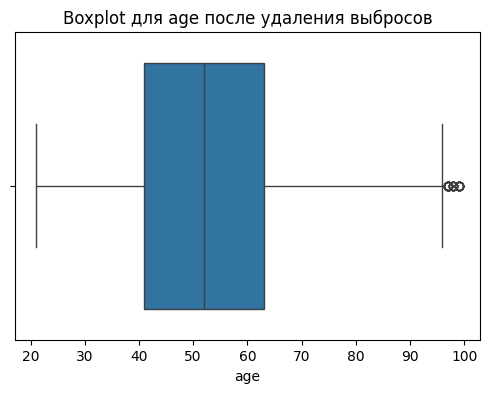

Нижняя теоретическая граница: 8.00
Верхняя теоретическая граница: 96.00
Значение нижнего уса: 21
Значение верхнего уса: 96


In [6]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['age'])
plt.title('Boxplot для age после удаления выбросов')
plt.savefig(os.path.join(FIGURES_DIR, 'boxplot_age_clean.png'), bbox_inches='tight')
plt.show()

# Расчёт границ "усов" для очищенного возраста
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

whisker_low = df[df['age'] >= lower_bound]['age'].min()
whisker_high = df[df['age'] <= upper_bound]['age'].max()

print(f"Нижняя теоретическая граница: {lower_bound:.2f}")
print(f"Верхняя теоретическая граница: {upper_bound:.2f}")
print(f"Значение нижнего уса: {whisker_low}")
print(f"Значение верхнего уса: {whisker_high}")

### 6. Разделение на признаки (X) и целевую переменную (y)

In [7]:
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

### 7. Масштабирование числовых признаков

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 8. Разделение на обучающую и валидационную выборки (стратификация)

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Валидационная выборка: {X_val.shape[0]} строк")

Обучающая выборка: 119773 строк
Валидационная выборка: 29944 строк


### 9. Сохранение обработанных данных и scaler

In [10]:
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

np.save('../data/processed/X_train_scaled.npy', X_train)
np.save('../data/processed/X_val_scaled.npy', X_val)
np.save('../data/processed/y_train.npy', y_train)
np.save('../data/processed/y_val.npy', y_val)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Данные сохранены в ../data/processed/")
print("Скалер сохранён в ../models/scaler.pkl")

Данные сохранены в ../data/processed/
Скалер сохранён в ../models/scaler.pkl


### 10. Проверка загрузки сохранённых данных

In [11]:
X_train_loaded = np.load('../data/processed/X_train_scaled.npy')
print(f"Проверка: X_train загружен, форма {X_train_loaded.shape}")

Проверка: X_train загружен, форма (119773, 10)
